# Homework 4

Jacobi and Gauss-Seidel comparison

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def jacobi(A, b, x0, tol, max_iterations):
    err = []
    n = len(b)
    x = x0.copy()
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        # Check for convergence
        err.append(np.linalg.norm(x_new - x, ord=np.inf))
        if err[-1] < tol:
            return x_new, k, err
        x = x_new
    return x, max_iterations, err

def gauss_seidel(A, b, x0, tol, max_iterations):
    err = []
    n = len(b)
    x = x0.copy()
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        # Check for convergence
        err.append(np.linalg.norm(x_new - x, ord=np.inf))
        if err[-1] < tol:
            return x_new, k, err
        x = x_new
    return x, max_iterations, err

## Testing

Tolerance:  0.001
        Jacobi: 3 iterations
  Gauss-Seidel: 3 iterations


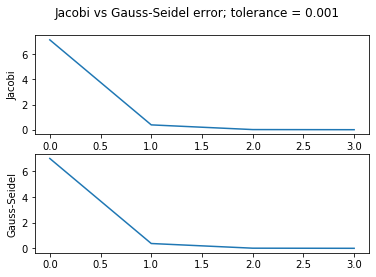



Tolerance:  1e-06
        Jacobi: 6 iterations
  Gauss-Seidel: 4 iterations


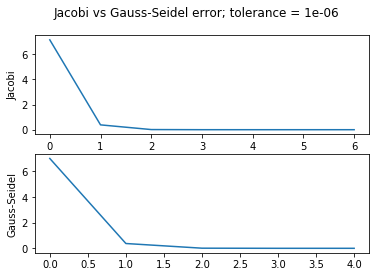



Tolerance:  1e-09
        Jacobi: 8 iterations
  Gauss-Seidel: 6 iterations


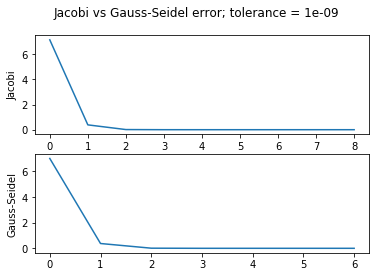

In [2]:
A = np.array([[3, -0.1, -0.2],
              [0.1, 7, -0.3],
              [0.3, -0.2, 10]])
b = np.array([7.85, -19.3, 71.4])

for tolerance in [0.001, 0.000001, 0.000000001]:
    _, n1, e1 = jacobi(A, b, np.array([0, 0, 0], dtype=float), tolerance, 100)
    _, n2, e2 = gauss_seidel(A, b, np.array([0, 0, 0], dtype=float), tolerance, 100)
    print("Tolerance: ", tolerance)
    print(f"        Jacobi: {n1} iterations")
    print(f"  Gauss-Seidel: {n2} iterations")
    plt.suptitle(f"Jacobi vs Gauss-Seidel error; tolerance = {tolerance}")
    plt.subplot(2,1,1)
    plt.plot(e1)
    plt.ylabel("Jacobi")
    plt.subplot(2,1,2)
    plt.plot(e2)
    plt.ylabel("Gauss-Seidel")
    plt.show()
    print("\n")

## Discussion

Gauss-Seidel consistently solves the problem is less iterations. This problem shows Jacobi using 30-50% more iterations for smaller tolerances, which could be narrowed down with even smaller tolerance or a harder set of equations.

The convergence graphs between methods for each tolerance are basically the same, the only difference being Jacobi taking more iterations with smaller tolerances.

Tolerance seems to affect the number of iterations on a logarithmic scale: each time the tolerance gets smaller by a factor of 1000, the number of iterations increases by 2 or 3 (addition vs multiplication).